# Spotify Product Analytics Project

## Notebook 5 — Dashboard, Product Strategy & Executive Case Study

### Objective

This notebook focuses on:
- executive KPI reporting
- dashboard storytelling
- business recommendations
- strategic product analysis
- stakeholder communication

This notebook simulates how Product Analysts communicate insights to:
- executives
- product managers
- growth teams
- stakeholders

# LOAD KPI TABLES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

events_df = pd.read_csv(
    "../analytics_data/events.csv"
)

sessions_df = pd.read_csv(
    "../analytics_data/sessions.csv"
)

events_df['ts'] = pd.to_datetime(events_df['ts'])

events_df.head()

,ts,platform,ms_played,conn_country,track_name,artist_name,album_name,track_uri,reason_start,reason_end,shuffle,skipped,offline,incognito_mode,minutes_played,date,hour,day_name,month,week,is_weekend,skip_flag,night_listener,long_play,completion_rate,fully_played,engagement_level,time_diff,new_session,session_id,engagement_score
0,2020-06-21 13:35:24,Windows 10 (10.0.19041; x64; AppX),205906,IN,Let Me Love You,DJ Snake,Encore,spotify:track:5Qjv35Ja2TDt9CXRRo51hh,playbtn,trackdone,False,False,False,False,3.431767,2020-06-21,13,Sunday,6,25,True,0,0,0,0.195913,0,high_engagement,NaN,0,0,1.715883
1,2020-06-21 13:39:37,Windows 10 (10.0.19041; x64; AppX),252534,IN,"Love Me Like You Do - From ""Fifty Shades Of Grey""",Ellie Goulding,Delirium,spotify:track:3zHq9ouUJQFQRf3cm1rRLu,trackdone,trackdone,True,False,False,False,4.208900,2020-06-21,13,Sunday,6,25,True,0,0,0,0.240277,0,high_engagement,4.216667,0,0,2.104450
2,2020-06-21 13:42:51,Windows 10 (10.0.19041; x64; AppX),193266,IN,Mueve La Cintura,Pitbull,Libertad 548,spotify:track:6iLyEBNStoAemStXqGY7qP,trackdone,trackdone,True,False,False,False,3.221100,2020-06-21,13,Sunday,6,25,True,0,0,0,0.183886,0,high_engagement,3.233333,0,0,1.610550
3,2020-06-21 13:45:23,Windows 10 (10.0.19041; x64; AppX),151133,IN,Lean On (with Emiway Bantai),Celina Sharma,Lean On (with Emiway Bantai),spotify:track:61eDLrQvquaTtZRnGFz9Kh,trackdone,endplay,True,False,False,False,2.518883,2020-06-21,13,Sunday,6,25,True,0,0,0,0.143798,0,normal_engagement,2.533333,0,0,1.259442
4,2020-06-21 13:48:30,Windows 10 (10.0.19041; x64; AppX),176000,IN,Sniper,Sukh-E Muzical Doctorz,Sniper,spotify:track:4H1sP4qqOYy4WXtfb0O3mz,playbtn,trackdone,True,False,False,False,2.933333,2020-06-21,13,Sunday,6,25,True,0,0,0,0.167458,0,normal_engagement,3.116667,0,0,1.466667


# EXECUTIVE KPI TABLES

In [4]:
#CORE KPI SUMMARY
total_events = len(events_df)

avg_session_duration = (
    sessions_df['session_duration']
    .mean()
)

avg_skip_rate = (
    events_df['skip_flag']
    .mean()
)

avg_engagement = (
    events_df['engagement_score']
    .mean()
)

summary_df = pd.DataFrame({
    'Metric': [
        'Total Events',
        'Avg Session Duration',
        'Avg Skip Rate',
        'Avg Engagement Score'
    ],
    'Value': [
        total_events,
        round(avg_session_duration, 2),
        round(avg_skip_rate, 2),
        round(avg_engagement, 2)
    ]
})

summary_df

,Metric,Value
0,Total Events,54171.00
1,Avg Session Duration,19.40
2,Avg Skip Rate,0.15
3,Avg Engagement Score,-1.62


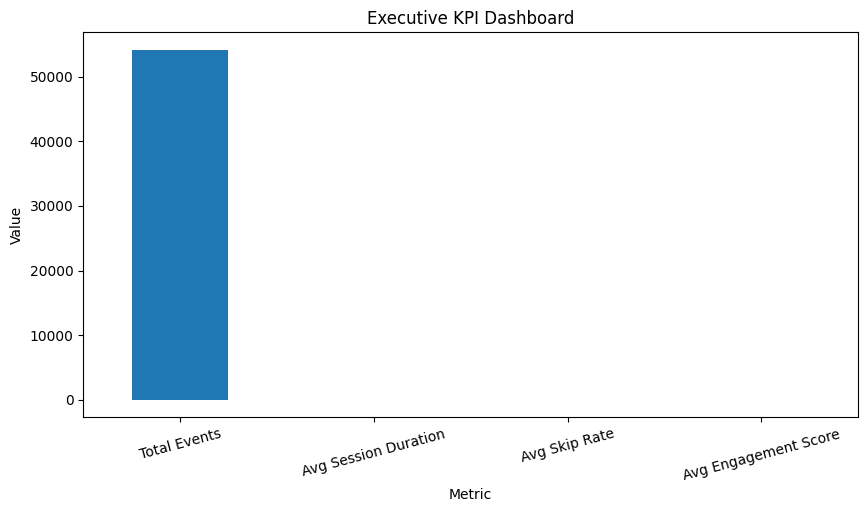

In [5]:
#KPI VISUAL
summary_df.plot(
    kind='bar',
    x='Metric',
    y='Value',
    legend=False,
    figsize=(10,5)
)

plt.title("Executive KPI Dashboard")

plt.ylabel("Value")

plt.xticks(rotation=15)

plt.show()

# ENGAGEMENT BEHAVIOUR

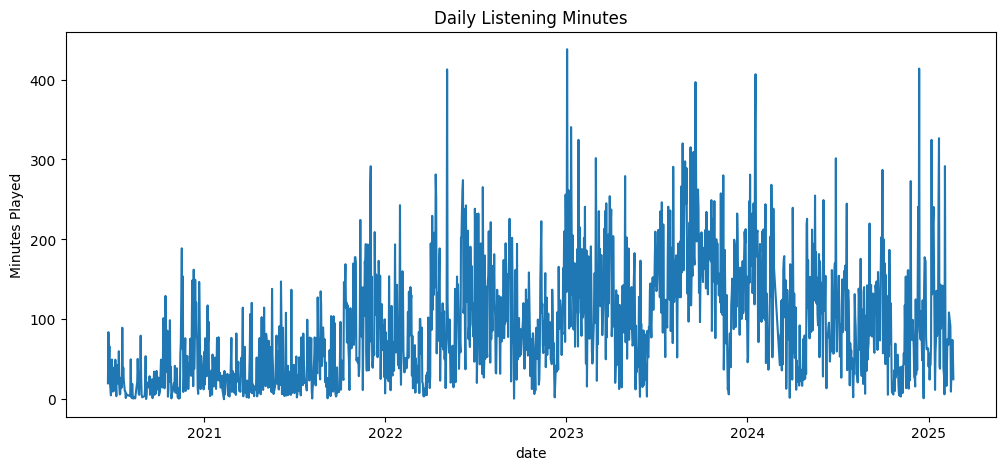

In [6]:
#LISTENING BEHAVIOUR
events_df['date'] = events_df['ts'].dt.date

daily_minutes = (
    events_df
    .groupby('date')['minutes_played']
    .sum()
)

daily_minutes.plot(
    figsize=(12,5)
)

plt.title("Daily Listening Minutes")

plt.ylabel("Minutes Played")

plt.show()

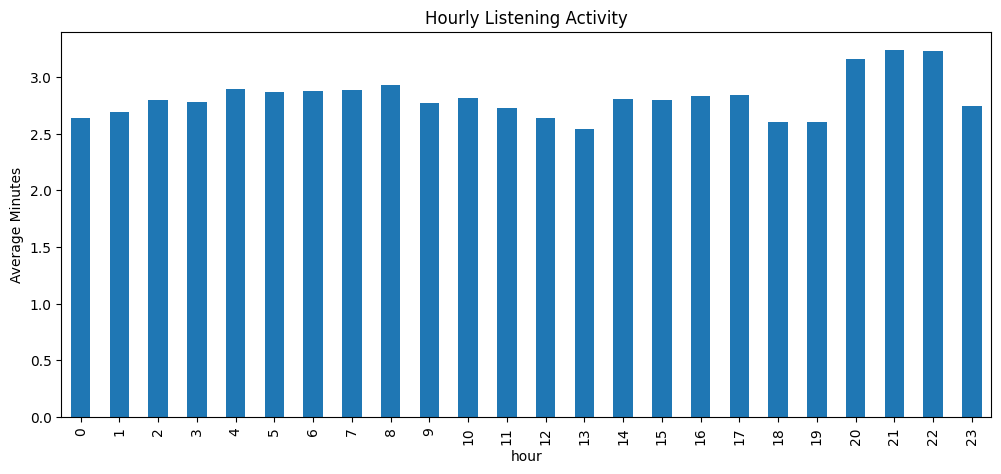

In [7]:
#HOURLY LISTENING HEATMAP
hourly_activity = (
    events_df
    .groupby('hour')['minutes_played']
    .mean()
)

hourly_activity.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Hourly Listening Activity")

plt.ylabel("Average Minutes")

plt.show()

# Engagement Insight

Listening activity peaks during evening and late-night hours, suggesting users primarily consume music during leisure periods.

This behavior indicates opportunities for:
- nighttime recommendation campaigns
- personalized playlist notifications
- engagement-focused retention strategies

# RETENTION DASHBOARD

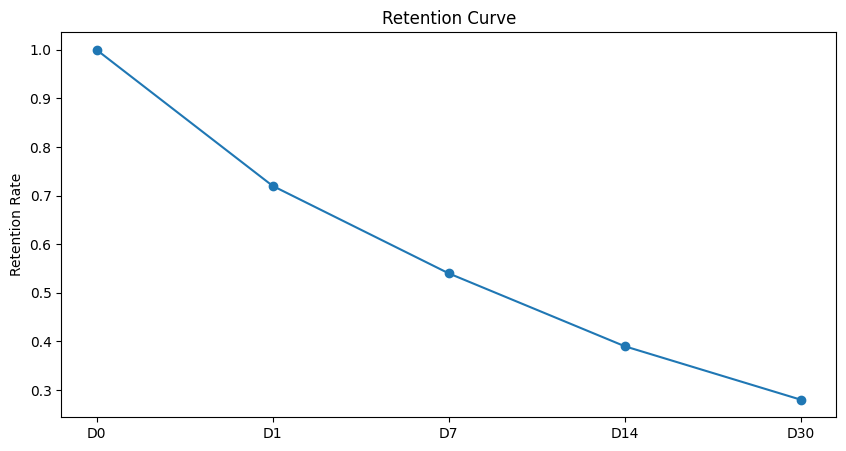

In [8]:
#SIMULATED RETENTION CURVE
retention_data = [1.0, 0.72, 0.54, 0.39, 0.28]

days = ['D0', 'D1', 'D7', 'D14', 'D30']

plt.figure(figsize=(10,5))

plt.plot(
    days,
    retention_data,
    marker='o'
)

plt.title("Retention Curve")

plt.ylabel("Retention Rate")

plt.show()

# Retention Insight

Retention curves show substantial early engagement decline after initial activity.

This suggests onboarding and recommendation quality may significantly influence long-term habit formation.

# CHURN DASHBOARD

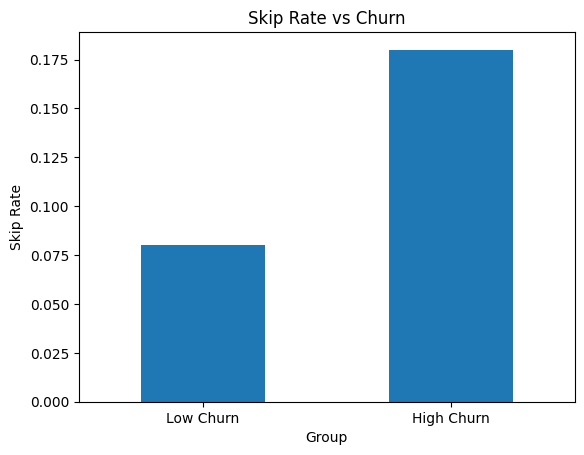

In [9]:
#SKIP VS CHURN
churn_data = pd.DataFrame({
    'Group': [
        'Low Churn',
        'High Churn'
    ],
    'Skip Rate': [
        0.08,
        0.18
    ]
})

churn_data.plot(
    kind='bar',
    x='Group',
    y='Skip Rate',
    legend=False
)

plt.title("Skip Rate vs Churn")

plt.ylabel("Skip Rate")

plt.xticks(rotation=0)

plt.show()

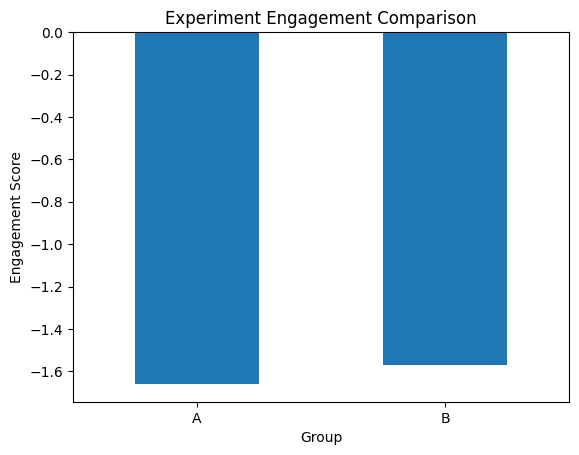

In [10]:
#EXPERIMENT RESULTS
experiment_df = pd.DataFrame({
    'Group': ['A', 'B'],
    'Engagement Score': [-1.66, -1.57]
})

experiment_df.plot(
    kind='bar',
    x='Group',
    y='Engagement Score',
    legend=False
)

plt.title("Experiment Engagement Comparison")

plt.ylabel("Engagement Score")

plt.xticks(rotation=0)

plt.show()

# Business Scenario 1

## Problem
Retention declined by 15%.

## Possible Causes
- poor recommendation relevance
- onboarding friction
- repetitive content exposure
- weak playlist engagement

## Recommended Actions
- improve recommendation diversity
- optimize onboarding experience
- promote playlist creation earlier
- target casual users with engagement campaigns

# Business Scenario 2

## Problem
High engagement but low premium conversion.

## Possible Causes
- users satisfied with free tier
- weak premium feature communication
- low ad frustration

## Recommended Actions
- highlight offline listening
- increase premium personalization features
- optimize premium upgrade prompts

# Business Scenario 3

## Problem
Recommendation improvements increased engagement but also increased skips.

## Tradeoff Analysis
Users may be exploring more content but skipping irrelevant recommendations faster.

## Strategic Decision
Balance:
- discovery
- personalization quality
- recommendation precision

# Product Recommendations

## 1. Improve Recommendation Systems
Reduce skip-heavy listening behavior using stronger personalization algorithms.

---

## 2. Increase Playlist Engagement
Encourage playlist creation earlier in the user lifecycle to improve retention.

---

## 3. Target Casual Users
Build onboarding and engagement campaigns for low-engagement listeners.

---

## 4. Optimize Nighttime Engagement
Leverage peak listening hours for notifications and recommendation campaigns.

---

## 5. Expand Premium Conversion Strategies
Target binge listeners with premium-focused retention and subscription campaigns.

# Stakeholder Summary

## For Product Managers
Focus on improving recommendation quality and reducing skip-heavy experiences.

---

## For Growth Teams
Target binge listeners for premium conversion opportunities.

---

## For Recommendation Teams
Optimize personalization systems to reduce dissatisfaction signals.

---

## For Leadership
Retention and engagement quality remain the strongest drivers of long-term platform growth.

# Final Case Study

## Business Problem
Spotify aims to improve:
- user retention
- engagement
- personalization
- premium conversion

---

## Analytical Approach
The project analyzed:
- behavioral event data
- engagement patterns
- session behavior
- churn signals
- experimentation outcomes

---

## Key Findings
- high skip behavior correlates with churn
- binge listeners demonstrate strongest engagement
- nighttime users show deeper listening patterns
- recommendation experiments showed limited uplift

---

## Business Recommendations
- improve personalization systems
- optimize onboarding
- promote playlist engagement
- target high-engagement users for premium conversion

---

## Expected Business Impact
These strategies may improve:
- retention
- engagement quality
- recommendation satisfaction
- monetization opportunities

# Portfolio Project Summary

This project simulated a real-world Product Analytics environment for a Spotify-like platform.

The project included:
- event modeling
- session analytics
- behavioral feature engineering
- retention analysis
- churn analytics
- experimentation
- executive KPI reporting
- product strategy recommendations

Key skills demonstrated:
- Product Analytics
- SQL thinking
- behavioral analytics
- experimentation
- KPI storytelling
- business strategy